# Diabetes Prediction Project

A structured machine learning pipeline for diabetes classification.

**Steps covered:**
1. Import Packages
2. Load Dataset
3. Data Cleaning
4. Exploratory Data Analysis
5. Feature Engineering
6. Model Training and Evaluation
7. Save Artifacts

---
## 1. Import Packages

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

from imblearn.over_sampling import SMOTE

import joblib

---
## 2. Load Dataset

In [2]:
df = pd.read_csv(r"C:\Users\ymoha\Desktop\LAST AI\Diabetes_dataset_last.csv")
df_copy = df.copy()
df_copy.head()

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\ymoha\\Desktop\\LAST AI\\Diabetes_dataset_last.csv'

In [ ]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 16 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   year                  150000 non-null  int64  
 1   gender                150000 non-null  object 
 2   age                   150000 non-null  float64
 3   location              150000 non-null  object 
 4   race:AfricanAmerican  150000 non-null  int64  
 5   race:Asian            150000 non-null  int64  
 6   race:Caucasian        150000 non-null  int64  
 7   race:Hispanic         150000 non-null  int64  
 8   race:Other            150000 non-null  int64  
 9   hypertension          150000 non-null  int64  
 10  heart_disease         150000 non-null  int64  
 11  smoking_history       150000 non-null  object 
 12  bmi                   150000 non-null  float64
 13  hbA1c_level           150000 non-null  float64
 14  blood_glucose_level   150000 non-null  int64  
 15  

In [ ]:
df_copy.describe()

,year,age,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,bmi,hbA1c_level,blood_glucose_level,diabetes
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000
mean,2016.999067,52.174347,0.177653,0.111093,0.512180,0.148633,0.050440,0.362807,0.090067,25.049704,6.178361,193.478080,0.540000
std,1.414755,18.882852,0.382222,0.314249,0.499853,0.355728,0.218852,0.480811,0.286278,4.542128,1.286154,76.447218,0.498399
min,2015.000000,18.000127,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,4.000000,60.000000,0.000000
25%,2016.000000,36.407095,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,21.500000,5.200000,132.000000,0.000000
50%,2017.000000,53.229769,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,24.810000,6.000000,182.000000,1.000000
75%,2018.000000,68.154764,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,28.520000,7.100000,250.000000,1.000000
max,2019.000000,84.998831,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,42.410000,9.000000,400.000000,1.000000


---
## 3. Data Cleaning

### 3.1 Missing Values

In [ ]:
df_copy.isna().mean() * 100

year                    0.0
gender                  0.0
age                     0.0
location                0.0
race:AfricanAmerican    0.0
race:Asian              0.0
race:Caucasian          0.0
race:Hispanic           0.0
race:Other              0.0
hypertension            0.0
heart_disease           0.0
smoking_history         0.0
bmi                     0.0
hbA1c_level             0.0
blood_glucose_level     0.0
diabetes                0.0
dtype: float64

### 3.2 Remove Duplicates

In [ ]:
print(df_copy.duplicated().sum())
df_copy = df_copy.drop_duplicates()

0


In [ ]:
# Confirm duplicates removed
print(df_copy.duplicated().sum())

0


---
## 4. Exploratory Data Analysis (EDA)

### 4.1 Target Distribution

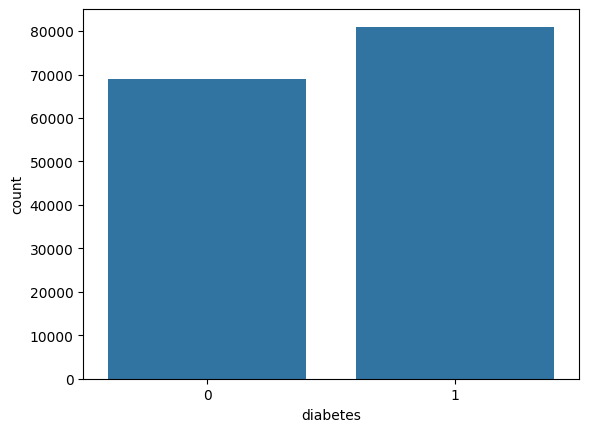

In [ ]:
sns.countplot(x='diabetes', data=df_copy)
plt.show()

### 4.2 Gender Distribution

<Axes: xlabel='gender', ylabel='Count'>

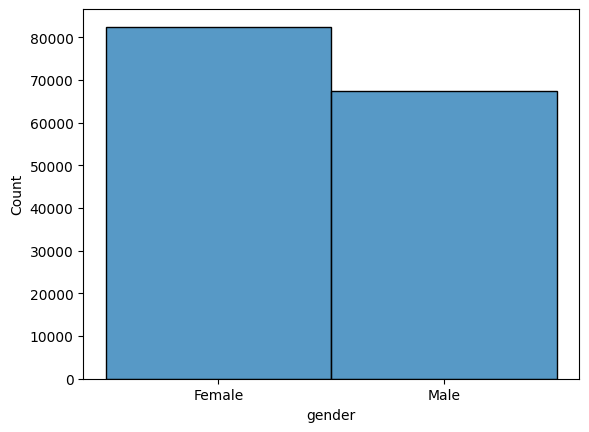

In [ ]:
sns.histplot(x='gender', data=df_copy)

### 4.3 Numerical Features - Boxplots

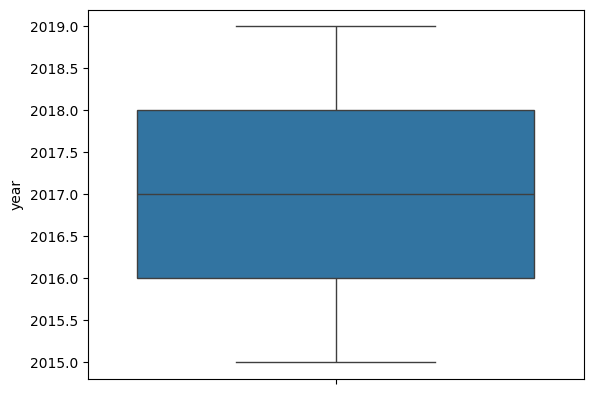

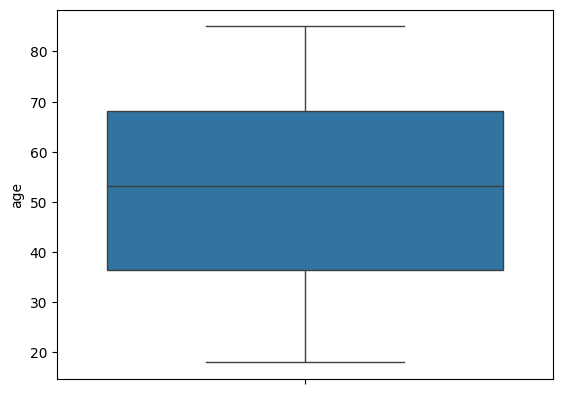

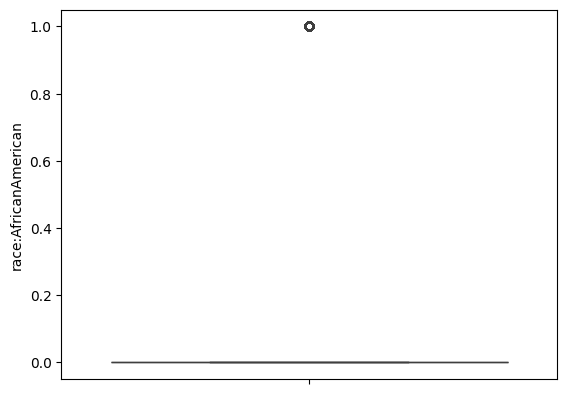

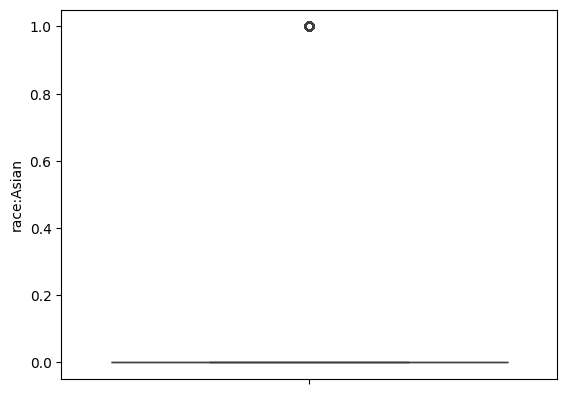

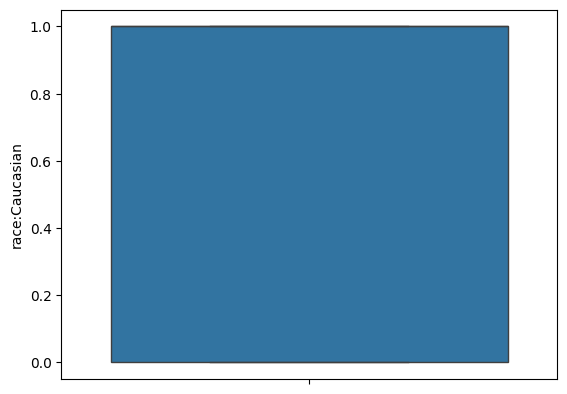

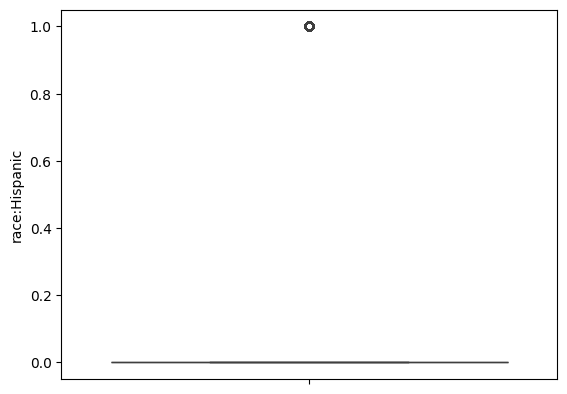

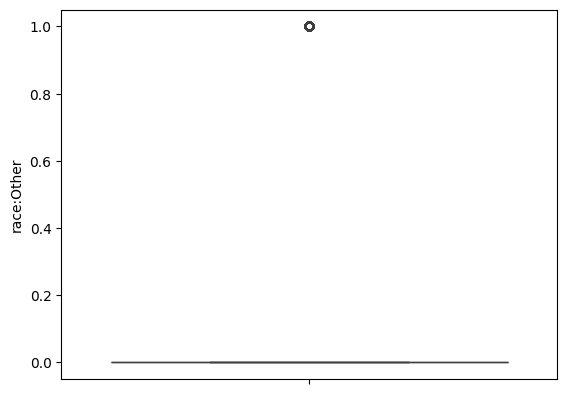

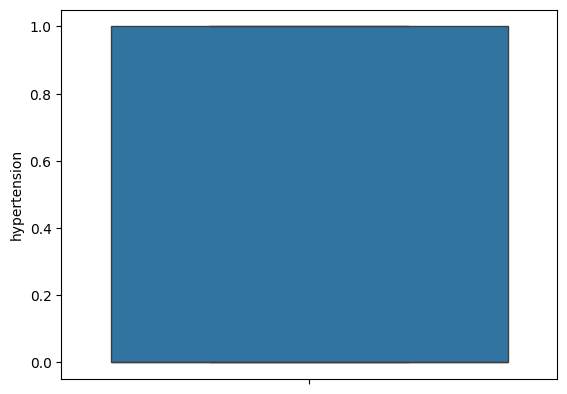

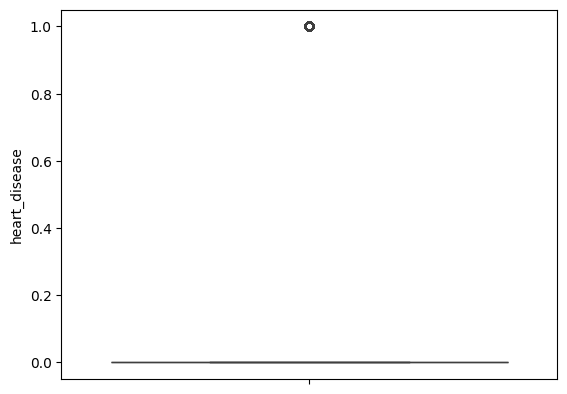

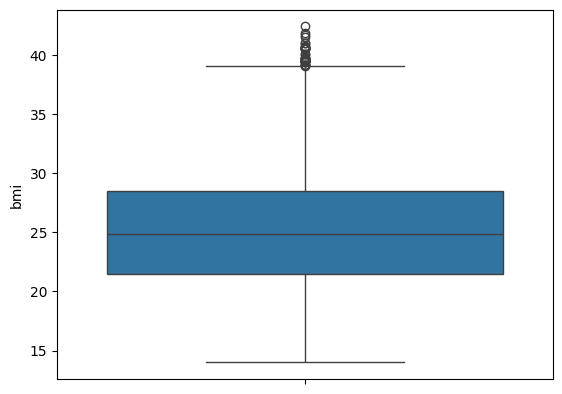

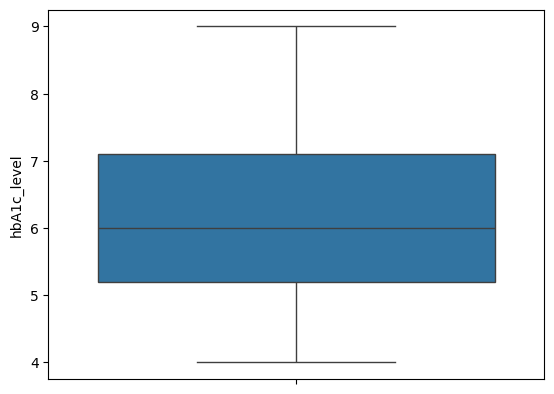

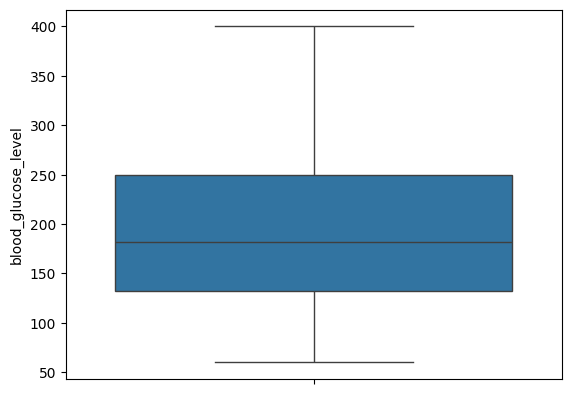

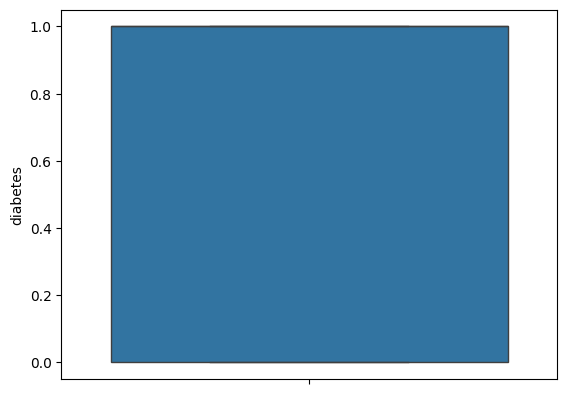

In [ ]:
cols = list(df_copy.select_dtypes(['int64', 'float64']))
for col in cols:
    sns.boxplot(y=col, data=df_copy)
    plt.show()

---
## 5. Feature Engineering

### 5.1 Drop Irrelevant Columns

In [ ]:
df_copy = df_copy.drop(
    columns=['year', 'location', 'race:AfricanAmerican', 'race:Asian',
             'race:Caucasian', 'race:Hispanic', 'race:Other']
)

In [ ]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               150000 non-null  object 
 1   age                  150000 non-null  float64
 2   hypertension         150000 non-null  int64  
 3   heart_disease        150000 non-null  int64  
 4   smoking_history      150000 non-null  object 
 5   bmi                  150000 non-null  float64
 6   hbA1c_level          150000 non-null  float64
 7   blood_glucose_level  150000 non-null  int64  
 8   diabetes             150000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 10.3+ MB


In [ ]:
df_copy.describe()

,age,hypertension,heart_disease,bmi,hbA1c_level,blood_glucose_level,diabetes
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000
mean,52.174347,0.362807,0.090067,25.049704,6.178361,193.478080,0.540000
std,18.882852,0.480811,0.286278,4.542128,1.286154,76.447218,0.498399
min,18.000127,0.000000,0.000000,14.000000,4.000000,60.000000,0.000000
25%,36.407095,0.000000,0.000000,21.500000,5.200000,132.000000,0.000000
50%,53.229769,0.000000,0.000000,24.810000,6.000000,182.000000,1.000000
75%,68.154764,1.000000,0.000000,28.520000,7.100000,250.000000,1.000000
max,84.998831,1.000000,1.000000,42.410000,9.000000,400.000000,1.000000


In [ ]:
df_copy.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level,diabetes
0,Female,41.667337,0,0,former,25.32,8.6,321,1
1,Female,35.053376,0,0,not current,18.47,6.4,194,0
2,Female,69.018596,0,1,No Info,27.78,5.9,199,1
3,Female,37.943587,0,0,never,24.98,5.9,149,0
4,Male,73.641528,0,0,never,28.06,5.7,205,1


### 5.2 Correlation Heatmap

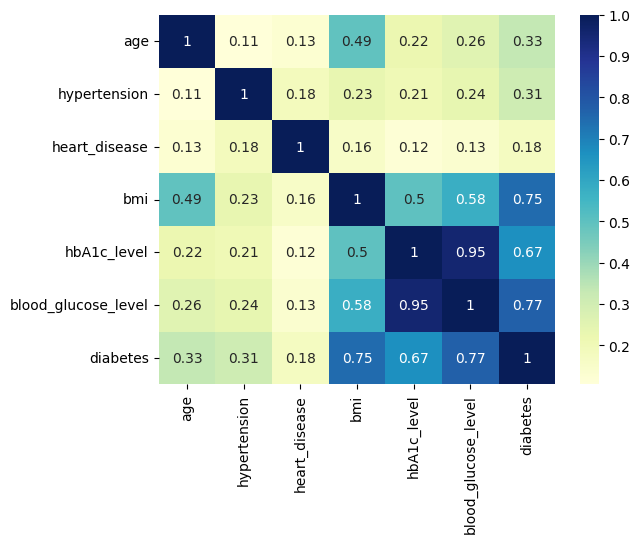

In [ ]:
num_data = df_copy.select_dtypes(['int64', 'float64'])
corr1 = num_data.corr()
sns.heatmap(corr1, annot=True, cmap="YlGnBu")
plt.show()

### 5.3 Encode Categorical Variables

**Gender** - binary, use Label Encoding

In [ ]:
le = LabelEncoder()
df_copy['gender'] = le.fit_transform(df_copy['gender'])
df_copy['gender']

0         0
1         0
2         0
3         0
4         1
         ..
149995    0
149996    1
149997    0
149998    0
149999    0
Name: gender, Length: 150000, dtype: int32

**Smoking History** - multi-class, use One-Hot Encoding

In [ ]:
df_copy = df_copy.reset_index(drop=True)

OHE = OneHotEncoder()
ohe_encoder = OHE.fit_transform(df_copy[['smoking_history']])
ohe_encoder_df = pd.DataFrame(
    ohe_encoder.toarray(),
    columns=OHE.get_feature_names_out(['smoking_history'])
)

df_copy = pd.concat([df_copy.drop('smoking_history', axis=1), ohe_encoder_df], axis=1)
df_copy.head()

,gender,age,hypertension,heart_disease,bmi,hbA1c_level,blood_glucose_level,diabetes,smoking_history_No Info,smoking_history_current,smoking_history_former,smoking_history_never,smoking_history_not current
0,0,41.667337,0,0,25.32,8.6,321,1,0.0,0.0,1.0,0.0,0.0
1,0,35.053376,0,0,18.47,6.4,194,0,0.0,0.0,0.0,0.0,1.0
2,0,69.018596,0,1,27.78,5.9,199,1,1.0,0.0,0.0,0.0,0.0
3,0,37.943587,0,0,24.98,5.9,149,0,0.0,0.0,0.0,1.0,0.0
4,1,73.641528,0,0,28.06,5.7,205,1,0.0,0.0,0.0,1.0,0.0


In [ ]:
# Confirm no missing values after encoding
df_copy.isna().mean() * 100

gender                         0.0
age                            0.0
hypertension                   0.0
heart_disease                  0.0
bmi                            0.0
hbA1c_level                    0.0
blood_glucose_level            0.0
diabetes                       0.0
smoking_history_No Info        0.0
smoking_history_current        0.0
smoking_history_former         0.0
smoking_history_never          0.0
smoking_history_not current    0.0
dtype: float64

---
## 6. Train-Test Split

In [ ]:
X = df_copy.drop('diabetes', axis=1)
y = df_copy['diabetes']

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=42)

---
## 7. Model Training

### 7.1 Logistic Regression (Baseline)

In [ ]:
logi = LogisticRegression()
logi.fit(X_train, y_train)

c:\Users\ymoha\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
y_pred_train = logi.predict(X_train)

Logistic Regression Performance:
              precision    recall  f1-score   support

           0       0.96      0.97      0.97     20602
           1       0.98      0.97      0.97     24398

    accuracy                           0.97     45000
   macro avg       0.97      0.97      0.97     45000
weighted avg       0.97      0.97      0.97     45000



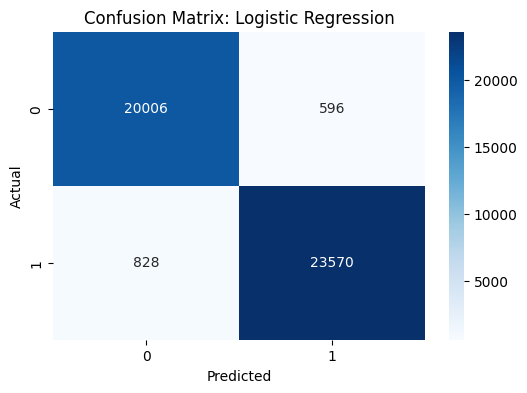

In [ ]:
y_pred_logi = logi.predict(X_test)

print("Logistic Regression Performance:")
print(classification_report(y_test, y_pred_logi))

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_logi), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### 7.2 Random Forest and XGBoost

In [ ]:
# Apply SMOTE to balance the training data
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

# Random Forest
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf.fit(X_train_balanced, y_train_balanced)
y_pred_rf = rf.predict(X_test)

# XGBoost
xgb = XGBClassifier(scale_pos_weight=10.6, use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train_balanced, y_train_balanced)
y_pred_xgb = xgb.predict(X_test)

print("Models trained successfully.")

Models trained successfully.


---
## 8. Model Comparison

In [ ]:
models_comparison = {
    "Logistic Regression": y_pred_logi,
    "Random Forest":       y_pred_rf,
    "XGBoost":             y_pred_xgb
}

for name, preds in models_comparison.items():
    print(f"\n--- {name} ---")
    print(f"F1-Score : {f1_score(y_test, preds):.4f}")
    print(f"Recall   : {recall_score(y_test, preds):.4f}")


--- Logistic Regression ---
F1-Score : 0.9707
Recall   : 0.9661

--- Random Forest ---
F1-Score : 0.9737
Recall   : 0.9694

--- XGBoost ---
F1-Score : 0.9610
Recall   : 0.9894


---
## 9. Save Artifacts

In [ ]:
# 1. Scaling (This defines the 'scaler' variable)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Train the models (Using scaled data for Logistic)
logi.fit(X_train_scaled, y_train)
rf.fit(X_train, y_train)
xgb.fit(X_train, y_train)

# 3. Save everything (The Artifacts)
# Saving the best model (XGBoost), the scaler, and encoders
joblib.dump(xgb, 'diabetes_model_final.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(le, 'gender_encoder.pkl')
joblib.dump(OHE, 'smoking_ohe.pkl')

feature_list = X.columns.tolist()
joblib.dump(feature_list, 'feature_list.pkl')

print("Success: Model, Scaler, and Feature List saved.")

Success: Model, Scaler, and Feature List saved.


---
## 10. Feature Documentation

In [ ]:
print("Final feature list (input order for prediction):")
for i, column in enumerate(X.columns):
    print(f"  {i}: {column}")

Final feature list (input order for prediction):
  0: gender
  1: age
  2: hypertension
  3: heart_disease
  4: bmi
  5: hbA1c_level
  6: blood_glucose_level
  7: smoking_history_No Info
  8: smoking_history_current
  9: smoking_history_former
  10: smoking_history_never
  11: smoking_history_not current
